In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.plots as plots # pyright: ignore[reportMissingImports]

from config import PROCESSED_DATA # pyright: ignore[reportMissingImports]
from statsmodels.tsa.seasonal import seasonal_decompose # pyright: ignore[reportMissingImports]

In [2]:
# Load the weekly fully observed product sales data
weekly_fully_observed_product_sales = pd.read_parquet(PROCESSED_DATA / 'weekly_fully_observed_product_sales.parquet')

In [3]:
# Display the first few rows of the weekly fully observed product sales data
weekly_fully_observed_product_sales.head(5)

,StockCode,InvoiceDate,Quantity,Revenue
0,15036,2010-12-06,79,62.96
1,15036,2010-12-13,21,20.52
2,15036,2010-12-20,37,34.64
3,15036,2010-12-27,24,18.00
4,15036,2011-01-10,37,41.00


In [4]:
# Calculate coefficient of variation (CV) for weekly sales quantity for each SKU
sku_cv = (
    weekly_fully_observed_product_sales
    .groupby("StockCode")["Quantity"]
    .agg(
        mean_qty="mean",
        std_qty="std"
    )
)

sku_cv["cv"] = (
    sku_cv["std_qty"] /
    sku_cv["mean_qty"]
)

# Identify stable, typical and volatile SKUs based on CV
stable_sku = sku_cv["cv"].idxmin()
typical_sku = (sku_cv["cv"] - sku_cv["cv"].median()).abs().idxmin()
volatile_sku = (sku_cv["cv"] - sku_cv["cv"].quantile(0.9)).abs().idxmin()

In [5]:
# 3 representative SKUs (stable / typical / volatile)
print(f"SKU: {stable_sku} - stable demand (CV:{sku_cv.loc[stable_sku, 'cv']:.2f})")
print(f"SKU: {typical_sku} - typical demand (CV:{sku_cv.loc[typical_sku, 'cv']:.2f})")
print(f"SKU: {volatile_sku} - volatile demand (CV:{sku_cv.loc[volatile_sku, 'cv']:.2f})")

SKU: 21931 - stable demand (CV:0.42)
SKU: 22492 - typical demand (CV:0.82)
SKU: 22752 - volatile demand (CV:1.39)


In [6]:
# Extract weekly sales data for the 3 representative SKUs
stable_sku_weekly_sales = weekly_fully_observed_product_sales[weekly_fully_observed_product_sales["StockCode"] == stable_sku].copy()
typical_sku_weekly_sales = weekly_fully_observed_product_sales[weekly_fully_observed_product_sales["StockCode"] == typical_sku].copy()
volatile_sku_weekly_sales = weekly_fully_observed_product_sales[weekly_fully_observed_product_sales["StockCode"] == volatile_sku].copy()

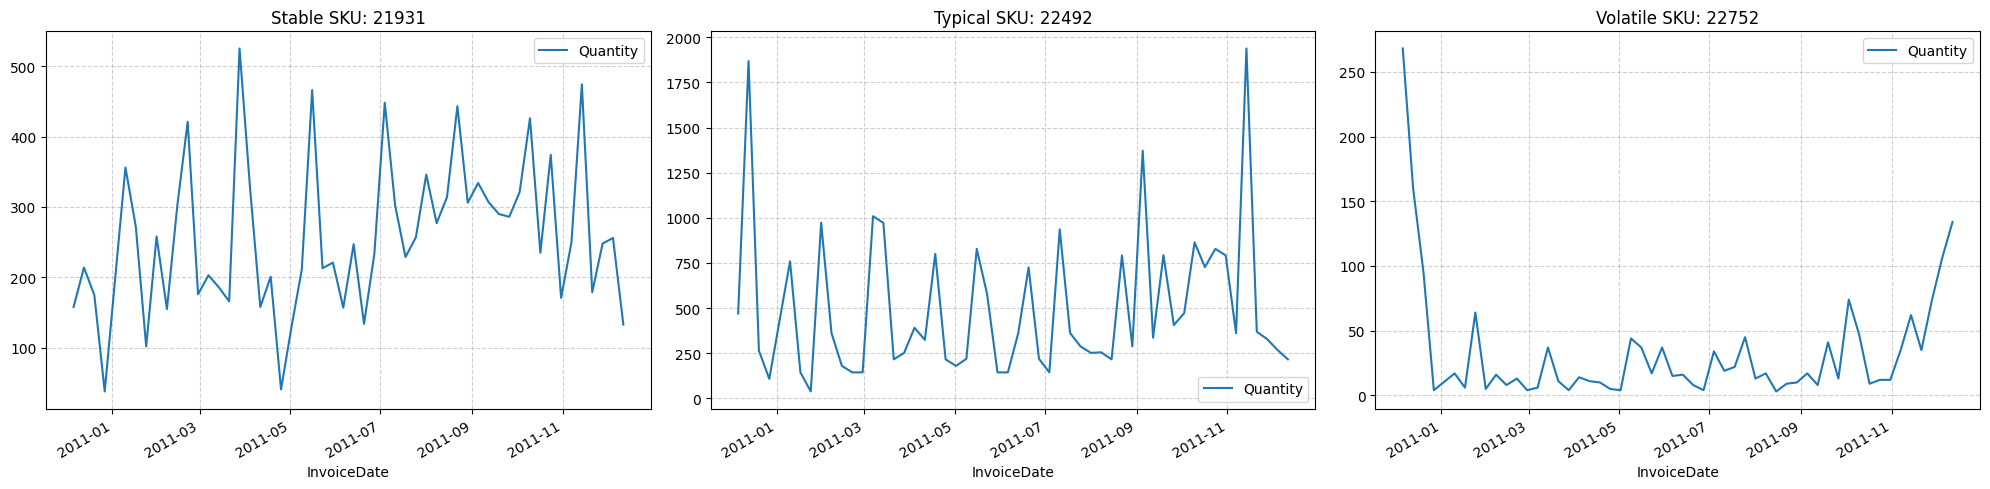

In [7]:
# Plot weekly sales quantity for the 3 representative SKUs
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

stable_sku_weekly_sales.plot(x="InvoiceDate", y="Quantity", title=f"Stable SKU: {stable_sku}", ax=axes[0])

typical_sku_weekly_sales.plot(x="InvoiceDate", y="Quantity", title=f"Typical SKU: {typical_sku}", ax=axes[1])

volatile_sku_weekly_sales.plot(x="InvoiceDate", y="Quantity", title=f"Volatile SKU: {volatile_sku}", ax=axes[2])

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#### Representative SKU Demand Dynamics

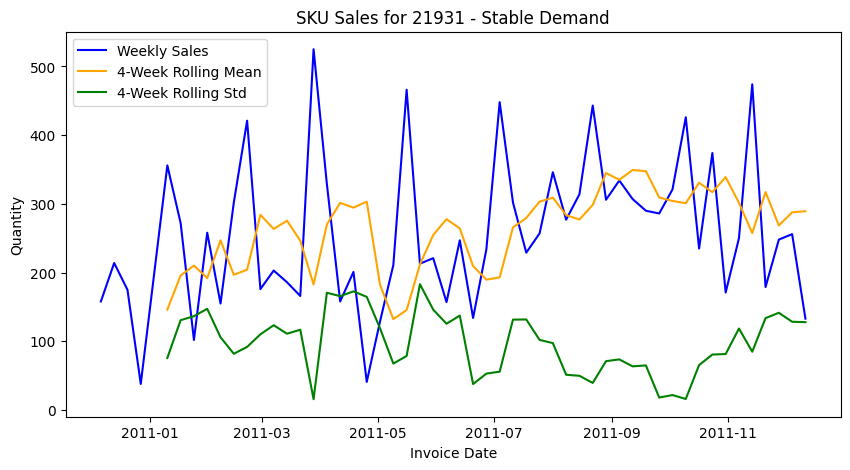

In [8]:
# For the stable SKU, calculate 4-week rolling mean and std of weekly sales quantity
stable_sku_weekly_sales["rolling_mean_4w"] = (stable_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .mean()
                                             )

# For the stable SKU, calculate 4-week rolling std of weekly sales quantity
stable_sku_weekly_sales["rolling_std_4w"] = (stable_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .std()
                                             )

# Plot weekly sales quantity with rolling mean and std for the stable SKU
plots.plot_weekly_sales_with_rolling_stats(
    stable_sku_weekly_sales,
    stable_sku,
    title_suffix="- Stable Demand"
)

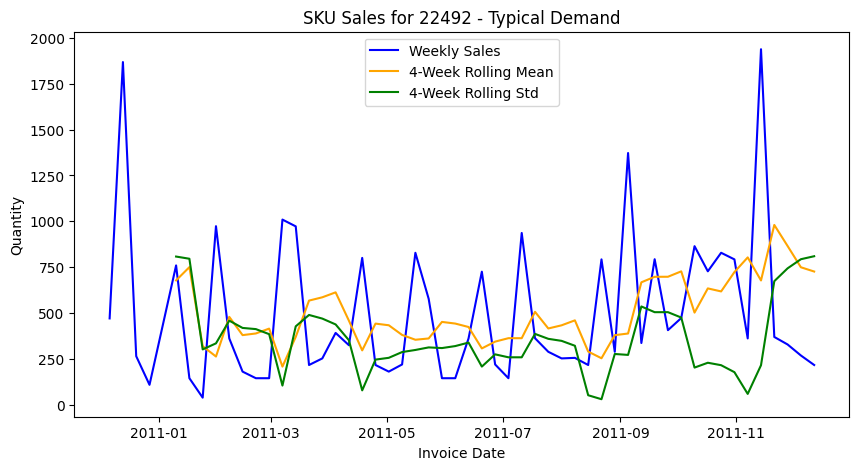

In [9]:
# For the typical SKU, calculate 4-week rolling mean and std of weekly sales quantity
typical_sku_weekly_sales["rolling_mean_4w"] = (typical_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .mean()
                                             )

# For the typical SKU, calculate 4-week rolling std of weekly sales quantity
typical_sku_weekly_sales["rolling_std_4w"] = (typical_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .std()
                                             )

# Plot weekly sales quantity with rolling mean and std for the typical SKU
plots.plot_weekly_sales_with_rolling_stats(
    typical_sku_weekly_sales,
    typical_sku,
    title_suffix="- Typical Demand"
)

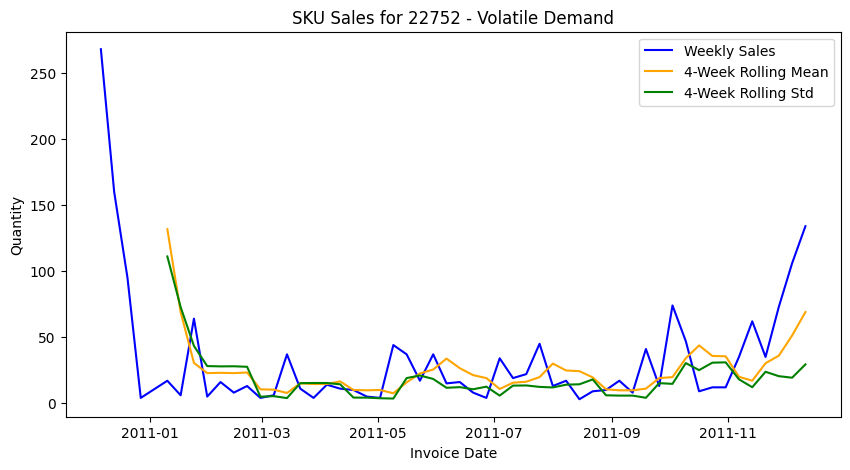

In [10]:
# For the volatile SKU, calculate 4-week rolling mean and std of weekly sales quantity
volatile_sku_weekly_sales["rolling_mean_4w"] = (volatile_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .mean()
                                             )

volatile_sku_weekly_sales["rolling_std_4w"] = (volatile_sku_weekly_sales["Quantity"]
                                             .shift(1)
                                             .rolling(4)
                                             .std()
                                             )

plots.plot_weekly_sales_with_rolling_stats(
    volatile_sku_weekly_sales,
    volatile_sku,
    title_suffix="- Volatile Demand"
)

In [ ]:
# Decompose the typical SKU weekly sales into trend and seasonal components using seasonal_decompose
typical_sku_weekly_sales_decomposed = typical_sku_weekly_sales.copy()
typical_sku_weekly_sales_decomposed = seasonal_decompose(
    typical_sku_weekly_sales_decomposed.set_index("InvoiceDate")["Quantity"],
    model="additive",
    period=13
)

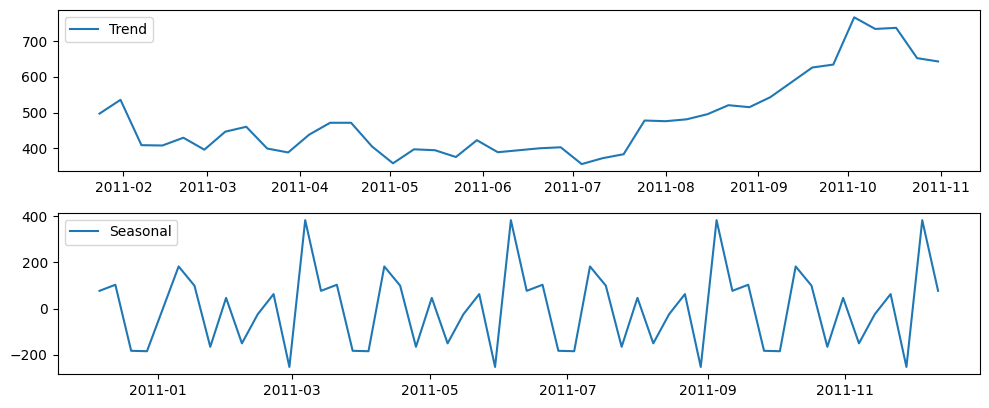

In [12]:
# PLot decomposed components for the typical SKU
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(typical_sku_weekly_sales_decomposed.trend, label="Trend")
plt.legend()

plt.subplot(412)
plt.plot(typical_sku_weekly_sales_decomposed.seasonal, label="Seasonal")
plt.legend()

plt.tight_layout()
plt.show()

Feature Engineering

In [13]:
# Create lag features for weekly sales quantity for the fully observed products
for w in [1, 2, 4, 8, 12]:
    weekly_fully_observed_product_sales[f"lag_{w}w_qty"] = weekly_fully_observed_product_sales.groupby("StockCode")["Quantity"].shift(w)

# Rolling mean per product shift(1) to avoid data leakage and rolling(4) to capture 1 month trend
weekly_fully_observed_product_sales["rolling_mean_4w_qty"] = (
    weekly_fully_observed_product_sales.groupby("StockCode")["Quantity"]
    .shift(1)
    .rolling(4)
    .mean()
)

# Rolling mean per product shift(1) to avoid data leakage and rolling(12) to capture 3 month trend
weekly_fully_observed_product_sales["rolling_mean_12w_qty"] = (
    weekly_fully_observed_product_sales.groupby("StockCode")["Quantity"]
    .shift(1)
    .rolling(12)
    .mean()
)

# Rolling std per product shift(1) to avoid data leakage and rolling(4) to capture 1 month variability
weekly_fully_observed_product_sales["rolling_std_4w_qty"] = (
    weekly_fully_observed_product_sales.groupby("StockCode")["Quantity"]
    .shift(1)
    .rolling(4)
    .std()
)

# Trend ratio: 4-week rolling mean / 12-week rolling mean to capture short-term vs long-term trend
weekly_fully_observed_product_sales["trend_ratio"] = weekly_fully_observed_product_sales["rolling_mean_4w_qty"] / weekly_fully_observed_product_sales["rolling_mean_12w_qty"]

# Volatility ratio: 4-week rolling std / 4-week rolling mean to capture relative variability
weekly_fully_observed_product_sales["rolling_cv_qty"] = weekly_fully_observed_product_sales["rolling_std_4w_qty"] / weekly_fully_observed_product_sales["rolling_mean_4w_qty"]

# Cyclical features for week of year (seasonality)
weekly_fully_observed_product_sales["sin_week"] = np.sin(2 * np.pi * weekly_fully_observed_product_sales["InvoiceDate"].dt.isocalendar().week / 52)
weekly_fully_observed_product_sales["cos_week"] = np.cos(2 * np.pi * weekly_fully_observed_product_sales["InvoiceDate"].dt.isocalendar().week / 52)
weekly_fully_observed_product_sales["is_q4"] = weekly_fully_observed_product_sales["InvoiceDate"].dt.quarter.eq(4).astype(int)

# Create a binary feature for December to capture potential end-of-year spike in demand
weekly_fully_observed_product_sales["is_december"] = weekly_fully_observed_product_sales["InvoiceDate"].dt.month.eq(12).astype(int)

# Create a feature for days to Christmas to capture proximity to a major holiday that can influence demand
weekly_fully_observed_product_sales["days_to_christmas"] = weekly_fully_observed_product_sales["InvoiceDate"].apply(
    lambda x: (pd.Timestamp(year=x.year, month=12, day=25) - x).days
    ).clip(0, 90)

In [14]:
# Display the first few rows of the weekly fully observed product sales data after feature engineering
weekly_fully_observed_product_sales.head(5)

,StockCode,InvoiceDate,Quantity,Revenue,lag_1w_qty,lag_2w_qty,lag_4w_qty,lag_8w_qty,lag_12w_qty,rolling_mean_4w_qty,rolling_mean_12w_qty,rolling_std_4w_qty,trend_ratio,rolling_cv_qty,sin_week,cos_week,is_q4,is_december,days_to_christmas
0,15036,2010-12-06,79,62.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.354605,0.935016,1,1,19
1,15036,2010-12-13,21,20.52,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239316,0.970942,1,1,12
2,15036,2010-12-20,37,34.64,21.0,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120537,0.992709,1,1,5
3,15036,2010-12-27,24,18.00,37.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1,0
4,15036,2011-01-10,37,41.00,24.0,37.0,79.0,NaN,NaN,40.25,NaN,26.750389,NaN,0.664606,0.239316,0.970942,0,0,90


In [15]:
# Save the weekly fully observed product sales data with features for modeling
weekly_fully_observed_product_sales.to_parquet(PROCESSED_DATA / 'modeling_df.parquet', index=False)